# **M4 Refinement Phase: Unsupervised Machine Learning for Grant "Era" Analysis**
**US Government Grant Opportunities Dataset**

By: Anna Baldzikowski


BA820 A1, Team 11

##**Domain Question:**

How have grant opportunity characteristics (agency, estimated funding, year posted, eligibility, category) evolved over time, and do distinct policy-era archetypes emerge in modern federal grantmaking?

##**Updates to Notebook:**

1.   Harnessing **K-prototypes clustering**, a form of synergy inspired by
Sambisha noted in M3. Here, I **provide deeper reasoning.**
2.   Discussion of **PCA being unnecessary/unapplicable**
3.   Improved **correlation matrix**, made more comprehensive
4. Added a section **Further Refinements**, where I explore clusters with different k=__ and random_state, to see if any significant findings improve
5. Added a section **Clustering with just larger Grants table to see if more insightful temporal eras emerge** (omitting eligibility and category)
6. Added a section **Text Mining Consideration/Note**
7. Updated **Business Insights**





## **Upload data to Colab**

In [ ]:
import pandas as pd

grants = pd.read_csv(
    "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2023/2023-10-03/grants.csv"
)

details = pd.read_csv(
    "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2023/2023-10-03/grant_opportunity_details.csv"
)


/tmp/ipython-input-1792275738.py:3: DtypeWarning: Columns (6,8,10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  grants = pd.read_csv(


## **Dataset Preliminary EDA: Pre-Clustering**

### **1. Dataset structure and coverage**

**Grants Table:**

In [ ]:
grants.shape

(74669, 17)

In [ ]:
grants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74669 entries, 0 to 74668
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   opportunity_id                  74669 non-null  int64  
 1   opportunity_number              74669 non-null  object 
 2   opportunity_title               74669 non-null  object 
 3   agency_code                     74626 non-null  object 
 4   agency_name                     74625 non-null  object 
 5   estimated_funding               53043 non-null  float64
 6   expected_number_of_awards       53371 non-null  object 
 7   grantor_contact                 74638 non-null  object 
 8   agency_contact_phone            668 non-null    object 
 9   agency_contact_email            73791 non-null  object 
 10  estimated_post_date             517 non-null    object 
 11  estimated_application_due_date  574 non-null    object 
 12  posted_date                     

**Details Table:**

In [ ]:
details.shape

(2000, 68)

In [ ]:
details.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 68 columns):
 #   Column                                                               Non-Null Count  Dtype  
---  ------                                                               --------------  -----  
 0   opportunity_id                                                       2000 non-null   int64  
 1   funding_opportunity_number                                           2000 non-null   object 
 2   funding_opportunity_title                                            2000 non-null   object 
 3   opportunity_category                                                 2000 non-null   object 
 4   opportunity_category_explanation                                     53 non-null     object 
 5   expected_number_of_awards                                            619 non-null    float64
 6   cost_sharing_or_matching_requirement                                 2000 non-null   bool   
 7   versio

In [ ]:
# Merge the tables
merged = grants.merge(details, on='opportunity_id', how='inner')

print("Merged rows:", len(merged))

# Just create posted_year for checking temporal coverage
merged['posted_year'] = pd.to_datetime(merged['posted_date_y']).dt.year

print("\nYear range in merged data:")
print(merged['posted_year'].agg(['min', 'max', 'count']))

print("\nYear distribution:")
print(merged['posted_year'].value_counts().sort_index())

print("\nAgency distribution (top 10):")
print(merged['agency_name_y'].value_counts().head(10))

# Check category columns
category_cols = [col for col in merged.columns if col.startswith('category_')]
print("\nNumber of category columns:", len(category_cols))

# Check eligibility columns
eligibility_cols = [col for col in merged.columns if col.startswith('eligibility_')]
print("Number of eligibility columns:", len(eligibility_cols))

Merged rows: 2000

Year range in merged data:
min      2004
max      2023
count    2000
Name: posted_year, dtype: int64

Year distribution:
posted_year
2004       1
2007       2
2008       2
2009       9
2010       5
2011       7
2012       7
2013       3
2014       7
2015      17
2016      10
2017      10
2018      38
2019      28
2020     125
2021     306
2022     400
2023    1023
Name: count, dtype: int64

Agency distribution (top 10):
agency_name_y
National Institutes of Health                       967
National Science Foundation                         276
Department of Commerce                               45
Dept. of the Army -- USAMRAA                         44
NASA Headquarters                                    43
Agency for International Development                 42
Environmental Protection Agency                      40
Fish and Wildlife Service                            27
National Energy Technology Laboratory                25
Centers for Disease Control and Prevent

In [ ]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 85 columns):
 #   Column                                                               Non-Null Count  Dtype  
---  ------                                                               --------------  -----  
 0   opportunity_id                                                       2000 non-null   int64  
 1   opportunity_number                                                   2000 non-null   object 
 2   opportunity_title                                                    2000 non-null   object 
 3   agency_code                                                          2000 non-null   object 
 4   agency_name_x                                                        2000 non-null   object 
 5   estimated_funding                                                    685 non-null    float64
 6   expected_number_of_awards_x                                          619 non-null    object 
 7   granto

**Analysis on merging tables:**
When selecting features to see if time-bound "eras" of funding emerge with unsupervised ML, I came to find that the Grants table did not include enough fruitful features to honor the question. The Grants table's features mainly capture administrative scale, not policy priorities. The Details table is needed to accurately evaluate if "eras" emerge, even though merging the tables makes the dataset smaller.


## **Unsupervised Machine Learning**

### **1. Preparing data for clustering: turning NAs to zeros**


In [ ]:
# Checking on posted_date_x vs posted_year
merged[['posted_date_x', 'posted_year']]

,posted_date_x,posted_year
0,2023-09-28,2023
1,2023-09-28,2023
2,2023-09-28,2023
3,2023-09-28,2023
4,2023-09-28,2023
...,...,...
1995,2008-07-22,2008
1996,2008-06-17,2008
1997,2007-11-28,2007
1998,2007-11-28,2007


**Analysis:** I am using k-prototypes to handle my mixed features- I recalled learning about this method briefly in class. Sambisha inspired my thinking about this, as she used k-modes on her categorical dataset.

This method makes much more sense than my **former k-means method** in M2, when I turned my categorical variables (agency name, eligibility, category) into all boolean 0s/1s. Mathematically speaking, when I one-hot encoded these categorical variables like "agency name," I was creating a set of binary dummy variables where the distances between categories are all artificially equal to the model. K-means was computing the means of these binary columns as cluster centroids- centroids that correspond to no real category.

**K-prototypes** solves this by using Hamming distance for categorical features, where the cluster prototype represents the most frequent category rather than a meaningless average. Numerical features still use euclidean distance. The two are combined, keeping distance calculations meaningful across both feature types simultaneously.

Features that will be used in unsupervised machine learning to see if time-bound "eras" are visible:


*   agency_name_x
*   estimated_funding
*   posted_year
*   eligibility
*   category

In [ ]:
merged['estimated_funding'] = merged['estimated_funding'].fillna(0)

Instead of dropping the NAs, in M3 my team and I found that filling NAs with 0s was optimal to preserve rows for the 3 of us (me, Maggie, Sambisha) who are limited to the 2000 row data.

###**2. Preprocessing: feature engineering, feature selection**

In [ ]:
# Checking for skewed estimated_funding (to see if it needs log transformation)
print("Estimated funding stats:")
print(merged['estimated_funding'].describe())
print("\nTop 5 values:")
print(merged['estimated_funding'].nlargest(5).values)

Estimated funding stats:
count    2.000000e+03
mean     4.438054e+07
std      4.856019e+08
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      2.840915e+06
max      1.397000e+10
Name: estimated_funding, dtype: float64

Top 5 values:
[1.3970e+10 9.6201e+09 7.0000e+09 6.0000e+09 5.0000e+09]


estimated_funding is largely skewed, so I will log transform it to compress extreme values.

In [ ]:
import numpy as np

merged['estimated_funding'] = np.log1p(merged['estimated_funding'])

I now will create top-10 agencies and "other" as to not overpower the clustering with all of the agencies (did this in M2 as well).

In [ ]:
top_10_agencies = (merged['agency_name_x'].value_counts().head(10).index)

merged['agency_simplified'] = merged['agency_name_x'].apply(
    lambda x: x if x in top_10_agencies else 'Other')

In [ ]:
print(top_10_agencies)

Index(['National Institutes of Health', 'National Science Foundation',
       'Department of Commerce', 'Dept. of the Army -- USAMRAA',
       'NASA Headquarters', 'Agency for International Development',
       'Environmental Protection Agency', 'Fish and Wildlife Service',
       'National Energy Technology Laboratory',
       'Centers for Disease Control and Prevention - ERA'],
      dtype='object', name='agency_name_x')


Columns to keep in my dataset for clustering:

In [ ]:
cols_to_keep = (
    ['estimated_funding', 'posted_year', 'agency_simplified'] +
    [col for col in merged.columns
     if col.startswith('eligibility_')] +
    [col for col in merged.columns
     if col.startswith('category_') and col != 'category_explanation']
)

df_cluster = merged[cols_to_keep].copy()

### **3. Evaluating to see if PCA is necessary**


First of all, **PCA is designed for continuous numeric variables.** It works by finding directions of maximum variance, which does not make sense for categorical or boolean data. Since I am already using k-prototypes which handles mixed data, I will skip PCA. But first I do want to **ensure that none of my features are too highly correlated!**

**Correlation matrix to show the 2 numeric variables**

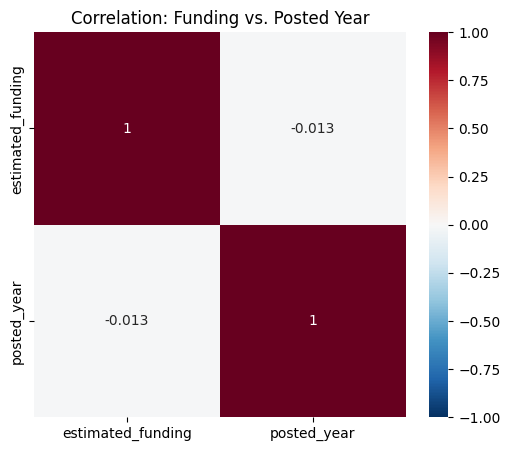

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Select only the two numeric columns
# Use .dropna() because correlation cannot be calculated with missing values
numeric_data = merged[['estimated_funding', 'posted_year']].dropna()

# Calculate the correlation matrix
# This will result in a 2x2 table showing how Year and Funding relate
corr_matrix = numeric_data.corr()

# Plot the Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix,
            annot=True,      # Shows the correlation number
            cmap='RdBu_r',   # Red for positive, Blue for negative
            center=0,
            vmin=-1, vmax=1) # Set the scale from -1 to 1

plt.title('Correlation: Funding vs. Posted Year')
plt.show()

**Correlation matrix to show boolean vs. numeric features**

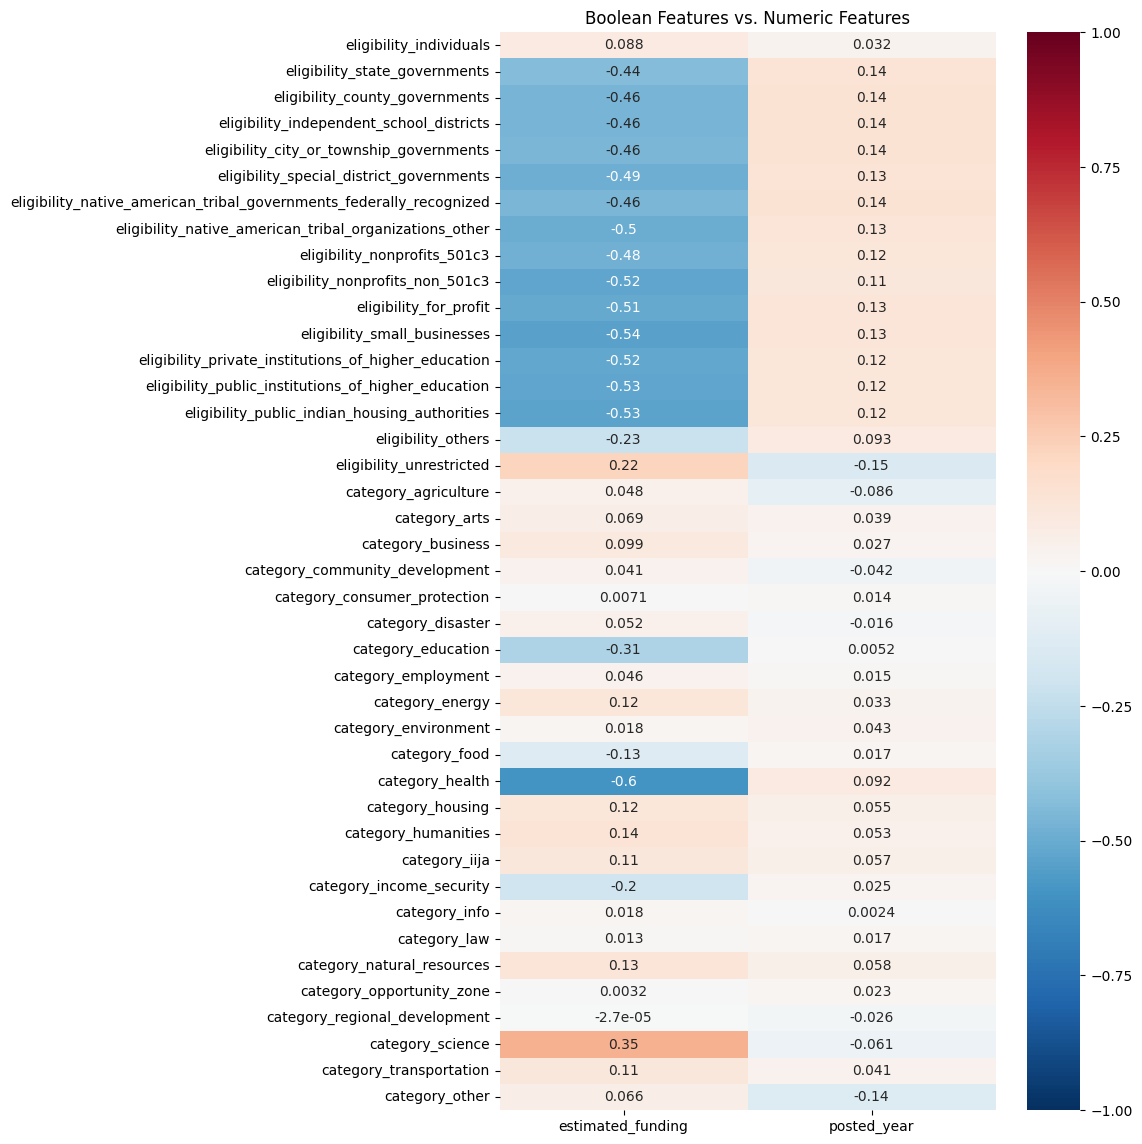

In [ ]:
numeric_cols = ['estimated_funding', 'posted_year']

corr_data = df_cluster.drop(columns=['agency_simplified']).dropna()
corr_with_numeric = corr_data.corr()[numeric_cols].drop(numeric_cols)

plt.figure(figsize=(8, 14))
sns.heatmap(corr_with_numeric, annot=True, cmap='RdBu_r', center=0, vmin=-1, vmax=1)
plt.title('Boolean Features vs. Numeric Features')
plt.show()

**Analysis:** None of these above features are highly correlated. Because agency_simplified is a string/object column (like "Department of Education", "Other")- I can't compute a correlation matrix. But all of my other variables are accounted for.

PCA wouldn't make sense because of my mixed (numeric + categorical/boolean) data, and it is a plus that none of it is highly correlated and therefore redundant!

### **4. Preprocessing: standardization**


Scaling numeric columns (doing this AFTER correlation plots because it would skew visualization):

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_cluster[['estimated_funding', 'posted_year']] = scaler.fit_transform(
    df_cluster[['estimated_funding', 'posted_year']]
)

Converting categorical variables to the correct datatypes that k-prototypes can handle.

In [ ]:
# Convert agency to string
df_cluster['agency_simplified'] = df_cluster['agency_simplified'].astype(str)

# Convert all boolean columns to string
bool_cols = df_cluster.select_dtypes(include='bool').columns
df_cluster[bool_cols] = df_cluster[bool_cols].astype(str)


### **5. Determining optimal number of clusters**


**Elbow method**

In [ ]:
!pip install kmodes

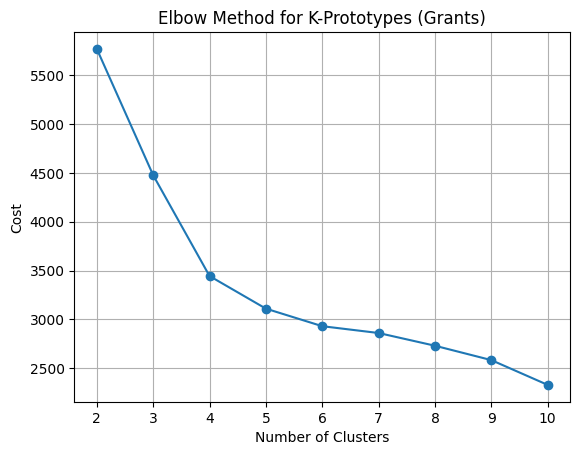

In [ ]:
from kmodes.kprototypes import KPrototypes
import matplotlib.pyplot as plt

costs = []

categorical_cols = list(range(2, df_cluster.shape[1]))

for k in range(2, 11):
    kproto = KPrototypes(
        n_clusters=k,
        init='Cao',
        n_init=5,
        verbose=0,
        random_state=42
    )

    clusters = kproto.fit_predict(
        df_cluster,
        categorical=categorical_cols
    )

    costs.append(kproto.cost_)

plt.plot(range(2, 11), costs, marker='o')
plt.title("Elbow Method for K-Prototypes (Grants)")
plt.xlabel("Number of Clusters")
plt.ylabel("Cost")
plt.grid(True)
plt.show()


**Analysis:** With keeping NAs as zeros and using k-prototypes, k=4 clusters looks to be optimal.

K-prototypes uses **.cost_** to find an elbow, and I see that k=4 produces an elbow, so I am going to try out k=4.

As k increases, each cluster gets smaller and more specific (less "dissimilarity"), so as points are closer to their prototype, cost drops. The "elbow" is where adding more clusters stops meaningfully reducing cost.

**Silhouette score** does not work  well with k-prototypes, because it expects numeric distances. K-prototypes uses euclidean (numeric) and matching dissimilarity (categorical). There is no built-in silhouette metric for mixed distance, so I will focus on this elbow plot (using cost scoring) above to choose my # clusters.

### **6. Run clustering**

In [ ]:
from kmodes.kprototypes import KPrototypes

# First two columns are numeric (funding, year)
categorical_cols = list(range(2, df_cluster.shape[1]))

kproto = KPrototypes(
    n_clusters=4,
    init='Cao', # This method initializes the centroids based on a distance and density-based approach, rather than picking random data points
    n_init=5,
    verbose=2,
    random_state=42
)

clusters = kproto.fit_predict(
    df_cluster,
    categorical=categorical_cols
)

df_cluster['cluster'] = clusters

Initialization method and algorithm are deterministic. Setting n_init to 1.
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 1, iteration: 1/100, moves: 116, ncost: 4604.051319851276
Run: 1, iteration: 2/100, moves: 16, ncost: 4592.3120958834215
Run: 1, iteration: 3/100, moves: 5, ncost: 4591.46820059398
Run: 1, iteration: 4/100, moves: 4, ncost: 4590.777922709327
Run: 1, iteration: 5/100, moves: 5, ncost: 4590.498718307751
Run: 1, iteration: 6/100, moves: 25, ncost: 4493.639966865642
Run: 1, iteration: 7/100, moves: 247, ncost: 3853.5314867939337
Run: 1, iteration: 8/100, moves: 154, ncost: 3461.7885524459443
Run: 1, iteration: 9/100, moves: 5, ncost: 3460.959783800183
Run: 1, iteration: 10/100, moves: 1, ncost: 3460.9086494485755
Run: 1, iteration: 11/100, moves: 0, ncost: 3460.9086494485755
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 2, iteration: 1/100, moves: 803, ncost: 3487.1990978685767
Run: 2, iterati

In [ ]:
import numpy as np
import pandas as pd

# --- STEP 1: CREATE A READABLE VERSION OF DATA ---
df_readable = df_cluster.copy()

# Reverse scaling and log math to get real numbers
df_readable[['estimated_funding', 'posted_year']] = scaler.inverse_transform(
    df_readable[['estimated_funding', 'posted_year']]
)
df_readable['estimated_funding'] = np.expm1(df_readable['estimated_funding'])

# Define our column lists
eligibility_cols = [col for col in df_readable.columns if col.startswith('eligibility_')]
category_cols = [col for col in df_readable.columns if col.startswith('category_')]

# --- STEP 2: DISCOVER THE CLUSTERS ---
for i in range(4):
    print("\n" + "="*60)
    print(f"               CLUSTER {i} ANALYSIS")
    print("="*60)

    c_data = df_readable[df_readable['cluster'] == i]
    total = len(c_data)

    # A. Stats & Funding
    print(f"Total Grants:   {total}")
    # NEW: Added Earliest and Latest year here
    print(f"Typical Year:   {int(c_data['posted_year'].median())}")
    print(f"Year Range:     {int(c_data['posted_year'].min())} to {int(c_data['posted_year'].max())}")
    print(f"Median Funding: ${c_data['estimated_funding'].median():,.2f}")
    print(f"Average Funding: ${c_data['estimated_funding'].mean():,.2f}")

    # B. Top 3 Agencies
    print("\nTop 3 Agencies:")
    agencies = c_data['agency_simplified'].value_counts().head(3)
    for name, count in agencies.items():
        print(f"  - {name}: {count} grants")

    # C. Top 3 Eligibility Types
    print("\nTop 3 Eligibility Types:")
    elig_counts = (c_data[eligibility_cols] == 'True').sum().sort_values(ascending=False).head(3)
    for col_name, count in elig_counts.items():
        clean_name = col_name.replace('eligibility_', '').replace('_', ' ')
        pct = (count / total) * 100
        print(f"  - {clean_name}: {int(pct)}% of cluster")

    # D. Top 3 Categories
    print("\nTop 3 Categories:")
    cat_counts = (c_data[category_cols] == 'True').sum().sort_values(ascending=False).head(3)
    for col_name, count in cat_counts.items():
        clean_name = col_name.replace('category_', '').replace('_', ' ')
        pct = (count / total) * 100
        print(f"  - {clean_name}: {int(pct)}% of cluster")


               CLUSTER 0 ANALYSIS
Total Grants:   956
Typical Year:   2022
Year Range:     2018 to 2023
Median Funding: $0.00
Average Funding: $1,286,369.25

Top 3 Agencies:
  - National Institutes of Health: 861 grants
  - Other: 47 grants
  - Centers for Disease Control and Prevention - ERA: 21 grants

Top 3 Eligibility Types:
  - state governments: 100% of cluster
  - independent school districts: 100% of cluster
  - county governments: 100% of cluster

Top 3 Categories:
  - health: 94% of cluster
  - education: 40% of cluster
  - income security: 16% of cluster

               CLUSTER 1 ANALYSIS
Total Grants:   81
Typical Year:   2014
Year Range:     2004 to 2018
Median Funding: $20,000.00
Average Funding: $80,575,163.70

Top 3 Agencies:
  - Other: 46 grants
  - National Science Foundation: 23 grants
  - Agency for International Development: 10 grants

Top 3 Eligibility Types:
  - others: 45% of cluster
  - unrestricted: 40% of cluster
  - nonprofits 501c3: 9% of cluster

Top 3 Ca

For the k-prototypes analysis (k=4), four distinct grant archetypes emerged:

**Cluster 0: The Modern Healthcare & Institutional Infrastructure Era (2018–2023).** This is the largest cluster **(956 grants)**, heavily concentrated in 2022 and dominated by the NIH (861 grants), with some CDC. The average award is over 1.2M dollars, which looks to be skewed up by some high amounts as the median is 0. It is defined by 100% eligibility for state and county governments and is overwhelmingly focused on Health (94%) and Education (40%), marking a highly specialized era of modern social infrastructure.

**Cluster 1: The Pre-Expansion Historical Baseline (2004–2018).** Representing an earlier era with a "typical year" of 2014, this smaller cluster **(81 grants)** reflects a more fragmented funding landscape. Interestingly, it features a massive average funding amount (80.5M) contrasted against a tiny 20k median, indicating a few extreme "mega-grants" among many small ones. Science (40%) is the lead category, but "Other" categories are high (22%), showing less thematic specialization than modern clusters.

**Cluster 2: High-Investment Science & STEM Innovation (2018–2023).** This cluster **(559 grants)** represents the "heavy hitters" of modern federal research, with a typical year of 2023 and a massive median funding of 10,000,000 dollars. Driven by the NSF (National Science Foundation) and the Department of the Army, it focuses primarily on Science (52%) and Environment (12%). It is characterized by high funding, reflecting large-scale federal investment in STEM and national security innovation.

**Cluster 3: Modern Non-Established-Funding Initiatives (2018–2023).** With **404 grants** and a typical year of 2023, this cluster is unique for having 0 dollars in both median and average funding, the grants that have "$0" or NA entered in estimated_funding, meaning grants in earlier development or without established/decided upon funding. At 404 grants, these are less so outliers and moreso a pattern to pay attention to. This cluster features a diverse mix of NIH, NASA, and "Other" agencies, with a blend of Science (39%) and Health (32%) categories, representing the diversification of federal grant formats in the current decade.

### **7. Deeper analysis of chosen k=4 clusters**

**Pairplot**

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

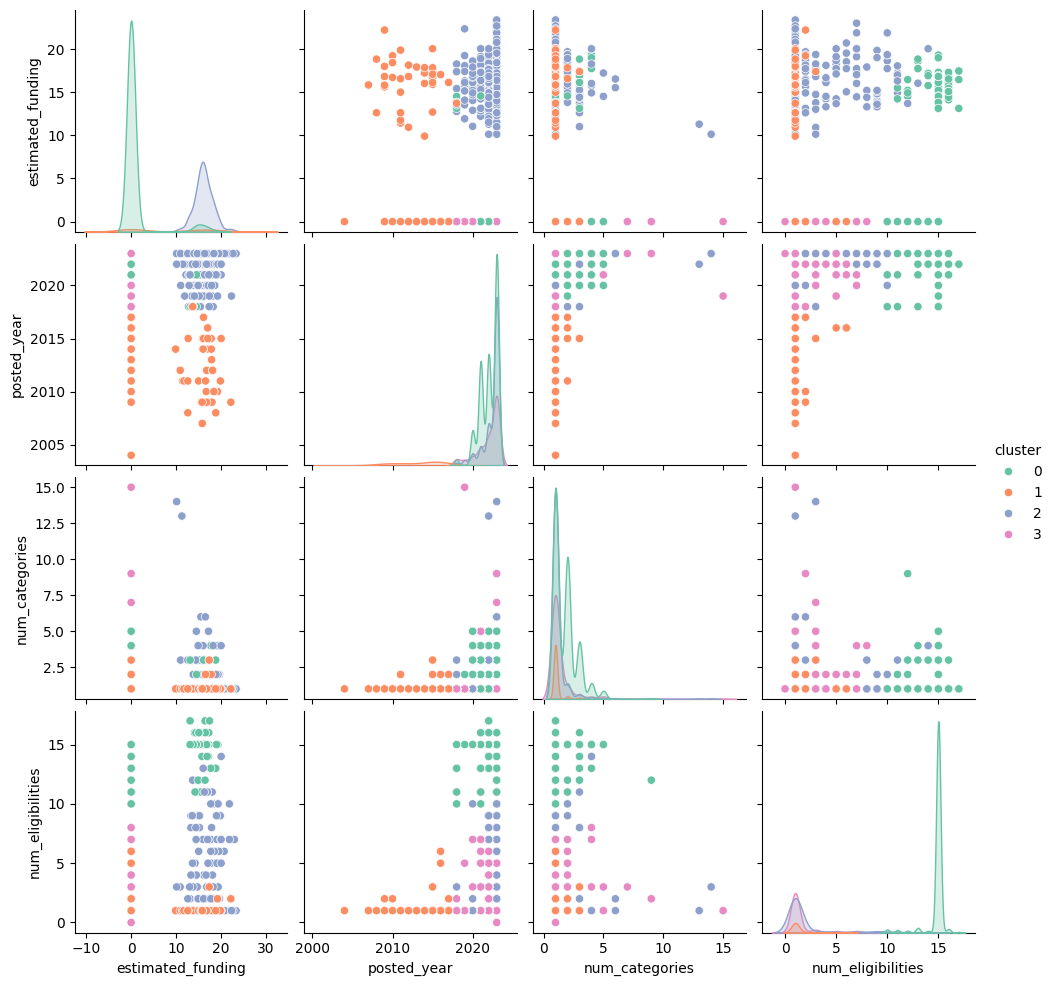

In [ ]:
# Create the copy
df_plot = df_cluster.copy()

# Fix the Standardization (turning back into readable numbers)
df_plot[['estimated_funding', 'posted_year']] = scaler.inverse_transform(df_plot[['estimated_funding', 'posted_year']])

# Create the missing columns by counting 'True' strings
# Search for the columns and count how many times 'True' appears in each row
elig_cols = [col for col in df_plot.columns if col.startswith('eligibility_')]
cat_cols = [col for col in df_plot.columns if col.startswith('category_') and col != 'category_explanation']

df_plot['num_eligibilities'] = (df_plot[elig_cols] == 'True').sum(axis=1)
df_plot['num_categories'] = (df_plot[cat_cols] == 'True').sum(axis=1)

sns.pairplot(df_plot[['estimated_funding', 'posted_year', 'num_categories', 'num_eligibilities', 'cluster']],
             hue="cluster",
             palette="Set2")

plt.show()

**Further insights into my clusters based on pairplot:**

**Cluster 0: The Modern Healthcare & Institutional Infrastructure Era (2018–2023).** Low to medium estimated funding- with some higher outliers, recent years, 0-5 number of categories typically with some reaching 10, high number of eligibilities hovering around 15.

**Cluster 1: The Pre-Expansion Historical Baseline (2004–2018).** Smallest cluster, wide array of estimated funding, earlier years, on the smaller end of number of categories/eligibilities.

**Cluster 2: High-Investment Science & STEM Innovation (2018–2023).** High estimated funding, recent modern years, low number of categories/eligibilities.

**Cluster 3: Modern Non-Established-Funding Initiatives (2018–2023).** No estimated funding, more recent years, low number of categories/eligibilities.

**Boxplots**

**Estimated Funding by Cluster**

In [ ]:
df_plot = df_cluster.copy()
df_plot[['estimated_funding', 'posted_year']] = scaler.inverse_transform(
    df_plot[['estimated_funding', 'posted_year']])

/tmp/ipython-input-919903924.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='cluster', y='estimated_funding', palette='Set2')


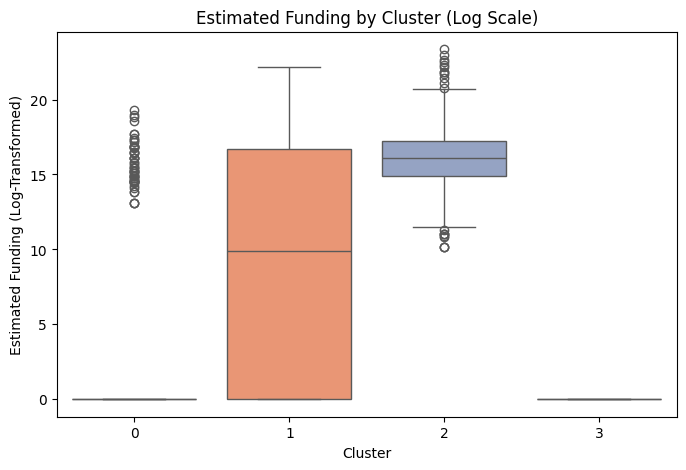

In [ ]:
# Boxplot for Funding (Log Scale)
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_plot, x='cluster', y='estimated_funding', palette='Set2')
plt.title('Estimated Funding by Cluster (Log Scale)')
plt.xlabel('Cluster')
plt.ylabel('Estimated Funding (Log-Transformed)')
plt.show()

**Analysis:** Cluster 2 represents a high-investment tier with a significantly higher median and a tight concentration of large-scale awards. Cluster 1 has the widest variety of funding amounts, spanning from small grants to large grants. Cluster 0 has low estimated funding but some outliers. Cluster 3 has 0 dollars in estimated funding.

**Posted Year by Cluster**

/tmp/ipython-input-4258542784.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='cluster', y='posted_year', palette='Set2')


Text(0, 0.5, 'Year')

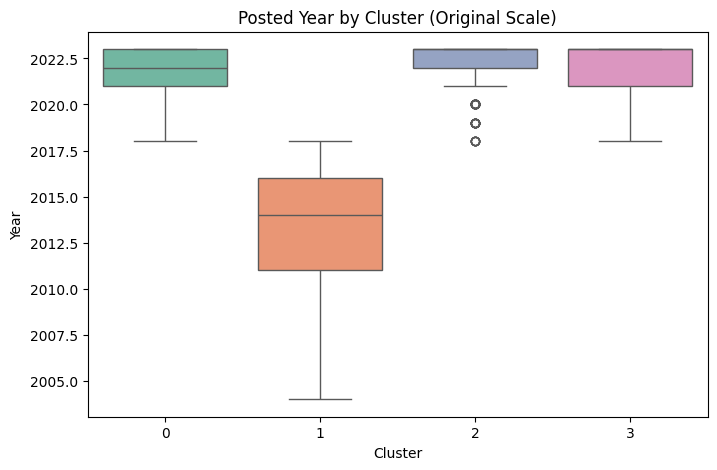

In [ ]:
# Boxplot for Posted Year (Actual Years)
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_plot, x='cluster', y='posted_year', palette='Set2')
plt.title('Posted Year by Cluster (Original Scale)')
plt.xlabel('Cluster')
plt.ylabel('Year')

**Analysis:** This year boxplot visually confirms my "Era" theory, showing a clear chronological split between the Cluster 1 historical baseline and the more recent activity in other clusters. While Cluster 1 covers a broad range centered around 2014, Clusters 0, 2, and 3 are tightly packed into the 2020s, illustrating a massive modern surge in federal grantmaking specialization (at least, whats tracked into the table). Unfortunately, clusters 0, 2, and 3 are not as differentiated by time as I initially hoped.

## **Further Refinements**

In this section, I will explore clusters with different k=__ and a different random_state seed, to see if any significant findings improve.


Above,
*   I used k=4
*   I used random_state=42

### **1. Attempting k=3 and k=5 as a robustness check**



While k=4 is the clear elbow on my elbow plot, k=3 and k=5 are other options I can try since they're adjacent to my k=4 and the curve still have some slope there. I will try both and show if my k=4 results hold up.

**k=3 Attempt**

In [ ]:
from kmodes.kprototypes import KPrototypes

# First two columns are numeric (funding, year)
categorical_cols = list(range(2, df_cluster.shape[1]))

kproto = KPrototypes(
    n_clusters=3,
    init='Cao', # This method initializes the centroids based on a distance and density-based approach, rather than picking random data points
    n_init=5,
    verbose=2,
    random_state=42
)

clusters = kproto.fit_predict(
    df_cluster,
    categorical=categorical_cols
)

df_cluster['cluster'] = clusters

Initialization method and algorithm are deterministic. Setting n_init to 1.
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 1, iteration: 1/100, moves: 462, ncost: 4685.334517729198
Run: 1, iteration: 2/100, moves: 62, ncost: 4670.1627454641175
Run: 1, iteration: 3/100, moves: 0, ncost: 4670.1627454641175
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 2, iteration: 1/100, moves: 165, ncost: 5693.930736966375
Run: 2, iteration: 2/100, moves: 56, ncost: 5666.189561772826
Run: 2, iteration: 3/100, moves: 5, ncost: 5666.132197167215
Run: 2, iteration: 4/100, moves: 0, ncost: 5666.132197167215
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 3, iteration: 1/100, moves: 215, ncost: 4650.278371494688
Run: 3, iteration: 2/100, moves: 2, ncost: 4650.266998937277
Run: 3, iteration: 3/100, moves: 0, ncost: 4650.266998937277
Init: initializing centroids
Init: initializing clusters
Startin

In [ ]:
# --- STEP 1: CREATE A READABLE VERSION OF DATA ---
df_readable = df_cluster.copy()

# Reverse scaling and log math to get real numbers
df_readable[['estimated_funding', 'posted_year']] = scaler.inverse_transform(
    df_readable[['estimated_funding', 'posted_year']]
)
df_readable['estimated_funding'] = np.expm1(df_readable['estimated_funding'])

# Define our column lists
eligibility_cols = [col for col in df_readable.columns if col.startswith('eligibility_')]
category_cols = [col for col in df_readable.columns if col.startswith('category_')]

# --- STEP 2: DISCOVER THE CLUSTERS ---
for i in range(3):  # changed from 4 to 3
    print("\n" + "="*60)
    print(f"               CLUSTER {i} ANALYSIS")
    print("="*60)

    c_data = df_readable[df_readable['cluster'] == i]
    total = len(c_data)

    # A. Stats & Funding
    print(f"Total Grants:   {total}")
    print(f"Typical Year:   {int(c_data['posted_year'].median())}")
    print(f"Year Range:     {int(c_data['posted_year'].min())} to {int(c_data['posted_year'].max())}")
    print(f"Median Funding: ${c_data['estimated_funding'].median():,.2f}")
    print(f"Average Funding: ${c_data['estimated_funding'].mean():,.2f}")

    # B. Top 3 Agencies
    print("\nTop 3 Agencies:")
    agencies = c_data['agency_simplified'].value_counts().head(3)
    for name, count in agencies.items():
        print(f"  - {name}: {count} grants")

    # C. Top 3 Eligibility Types
    print("\nTop 3 Eligibility Types:")
    elig_counts = (c_data[eligibility_cols] == 'True').sum().sort_values(ascending=False).head(3)
    for col_name, count in elig_counts.items():
        clean_name = col_name.replace('eligibility_', '').replace('_', ' ')
        pct = (count / total) * 100
        print(f"  - {clean_name}: {int(pct)}% of cluster")

    # D. Top 3 Categories
    print("\nTop 3 Categories:")
    cat_counts = (c_data[category_cols] == 'True').sum().sort_values(ascending=False).head(3)
    for col_name, count in cat_counts.items():
        clean_name = col_name.replace('category_', '').replace('_', ' ')
        pct = (count / total) * 100
        print(f"  - {clean_name}: {int(pct)}% of cluster")


               CLUSTER 0 ANALYSIS
Total Grants:   960
Typical Year:   2022
Year Range:     2018 to 2023
Median Funding: $0.00
Average Funding: $1,281,009.37

Top 3 Agencies:
  - National Institutes of Health: 865 grants
  - Other: 47 grants
  - Centers for Disease Control and Prevention - ERA: 21 grants

Top 3 Eligibility Types:
  - public institutions of higher education: 99% of cluster
  - nonprofits 501c3: 99% of cluster
  - county governments: 99% of cluster

Top 3 Categories:
  - health: 94% of cluster
  - education: 40% of cluster
  - income security: 16% of cluster

               CLUSTER 1 ANALYSIS
Total Grants:   479
Typical Year:   2022
Year Range:     2004 to 2023
Median Funding: $0.00
Average Funding: $12,464,693.65

Top 3 Agencies:
  - Other: 217 grants
  - National Institutes of Health: 102 grants
  - National Science Foundation: 64 grants

Top 3 Eligibility Types:
  - others: 49% of cluster
  - unrestricted: 28% of cluster
  - public institutions of higher education: 14

**Analysis:** For the k-prototypes analysis (k=3), the "eras" that emerged are less differentiated by year than my k=4 clusters. Here, cluster 0 is similar to cluster 0 in my k-4 clustering, but cluster 1 ranges from 2004 to 2023-- the entire range of years I'm analyzing- and cluster 2 ranges from 2014 to 2023. My former clusters had a distinct "older" era, and with 1 extra cluster they also provided more in-depth insights.

**k=5 Attempt**

In [ ]:
from kmodes.kprototypes import KPrototypes

# First two columns are numeric (funding, year)
categorical_cols = list(range(2, df_cluster.shape[1]))

kproto = KPrototypes(
    n_clusters=5,
    init='Cao', # This method initializes the centroids based on a distance and density-based approach, rather than picking random data points
    n_init=5,
    verbose=2,
    random_state=42
)

clusters = kproto.fit_predict(
    df_cluster,
    categorical=categorical_cols
)

df_cluster['cluster'] = clusters

Initialization method and algorithm are deterministic. Setting n_init to 1.
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 1, iteration: 1/100, moves: 189, ncost: 3121.071003139634
Run: 1, iteration: 2/100, moves: 5, ncost: 3120.7484888140066
Run: 1, iteration: 3/100, moves: 0, ncost: 3120.7484888140066
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 2, iteration: 1/100, moves: 260, ncost: 3279.1829902085196
Run: 2, iteration: 2/100, moves: 3, ncost: 3279.056064339449
Run: 2, iteration: 3/100, moves: 0, ncost: 3279.056064339449
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 3, iteration: 1/100, moves: 1057, ncost: 3530.186895978693
Run: 3, iteration: 2/100, moves: 310, ncost: 3134.005342637062
Run: 3, iteration: 3/100, moves: 21, ncost: 3118.4942520791315
Run: 3, iteration: 4/100, moves: 0, ncost: 3118.4942520791315
Init: initializing centroids
Init: initializing clusters
St

In [ ]:
# --- STEP 1: CREATE A READABLE VERSION OF DATA ---
df_readable = df_cluster.copy()

# Reverse scaling and log math to get real numbers
df_readable[['estimated_funding', 'posted_year']] = scaler.inverse_transform(
    df_readable[['estimated_funding', 'posted_year']]
)
df_readable['estimated_funding'] = np.expm1(df_readable['estimated_funding'])

# Define our column lists
eligibility_cols = [col for col in df_readable.columns if col.startswith('eligibility_')]
category_cols = [col for col in df_readable.columns if col.startswith('category_')]

# --- STEP 2: DISCOVER THE CLUSTERS ---
for i in range(5):  # changed to 5
    print("\n" + "="*60)
    print(f"               CLUSTER {i} ANALYSIS")
    print("="*60)

    c_data = df_readable[df_readable['cluster'] == i]
    total = len(c_data)

    # A. Stats & Funding
    print(f"Total Grants:   {total}")
    print(f"Typical Year:   {int(c_data['posted_year'].median())}")
    print(f"Year Range:     {int(c_data['posted_year'].min())} to {int(c_data['posted_year'].max())}")
    print(f"Median Funding: ${c_data['estimated_funding'].median():,.2f}")
    print(f"Average Funding: ${c_data['estimated_funding'].mean():,.2f}")

    # B. Top 3 Agencies
    print("\nTop 3 Agencies:")
    agencies = c_data['agency_simplified'].value_counts().head(3)
    for name, count in agencies.items():
        print(f"  - {name}: {count} grants")

    # C. Top 3 Eligibility Types
    print("\nTop 3 Eligibility Types:")
    elig_counts = (c_data[eligibility_cols] == 'True').sum().sort_values(ascending=False).head(3)
    for col_name, count in elig_counts.items():
        clean_name = col_name.replace('eligibility_', '').replace('_', ' ')
        pct = (count / total) * 100
        print(f"  - {clean_name}: {int(pct)}% of cluster")

    # D. Top 3 Categories
    print("\nTop 3 Categories:")
    cat_counts = (c_data[category_cols] == 'True').sum().sort_values(ascending=False).head(3)
    for col_name, count in cat_counts.items():
        clean_name = col_name.replace('category_', '').replace('_', ' ')
        pct = (count / total) * 100
        print(f"  - {clean_name}: {int(pct)}% of cluster")


               CLUSTER 0 ANALYSIS
Total Grants:   512
Typical Year:   2023
Year Range:     2018 to 2023
Median Funding: $9,450,000.00
Average Funding: $119,980,112.63

Top 3 Agencies:
  - National Science Foundation: 211 grants
  - Other: 156 grants
  - Dept. of the Army -- USAMRAA: 42 grants

Top 3 Eligibility Types:
  - others: 61% of cluster
  - unrestricted: 27% of cluster
  - state governments: 5% of cluster

Top 3 Categories:
  - science: 56% of cluster
  - environment: 12% of cluster
  - other: 8% of cluster

               CLUSTER 1 ANALYSIS
Total Grants:   81
Typical Year:   2014
Year Range:     2004 to 2018
Median Funding: $20,000.00
Average Funding: $80,575,163.70

Top 3 Agencies:
  - Other: 46 grants
  - National Science Foundation: 23 grants
  - Agency for International Development: 10 grants

Top 3 Eligibility Types:
  - others: 45% of cluster
  - unrestricted: 40% of cluster
  - nonprofits 501c3: 9% of cluster

Top 3 Categories:
  - science: 40% of cluster
  - other: 22

**Analysis:** This k=5 clustering does have an "older" era, cluster 1- from 2004 to 2018. From the larger NIH cluster 0 in k=4, k=5 clusters peeled off a small high-funding local-government-focused health subgroup (cluster 2). This is a pretty subtle distinction that doesn't add a meaningfully new archetype for my research question about policy eras. K=4 remains more interpretable, as k=5 is more fragmented.

Ultimately, k=4 remains the best fit for my research question, as k=5 does not reveal any distinct **new time-bound eras** and instead splits the modern healthcare cluster (cluster 0 in k=4). **My domain question seeks temporal eras.** However, the k=5 sensitivity test did surface a notable subpattern- a CDC-dominated, high-funded local-government channel consistent with COVID-era emergency response funding- which is discussed further in the **sharpened business insights section**.

### **2. Attempting a different random_state for k=4 as a robustness check**


In [ ]:
from kmodes.kprototypes import KPrototypes

# First two columns are numeric (funding, year)
categorical_cols = list(range(2, df_cluster.shape[1]))

kproto = KPrototypes(
    n_clusters=4,
    init='Cao', # This method initializes the centroids based on a distance and density-based approach, rather than picking random data points
    n_init=5,
    verbose=2,
    random_state=3 # Switched random_state to 3
)

clusters = kproto.fit_predict(
    df_cluster,
    categorical=categorical_cols
)

df_cluster['cluster'] = clusters

Initialization method and algorithm are deterministic. Setting n_init to 1.
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 1, iteration: 1/100, moves: 283, ncost: 3508.1469221891102
Run: 1, iteration: 2/100, moves: 21, ncost: 3496.346370364099
Run: 1, iteration: 3/100, moves: 0, ncost: 3496.346370364099
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 2, iteration: 1/100, moves: 485, ncost: 4331.166427603568
Run: 2, iteration: 2/100, moves: 37, ncost: 4326.422600988824
Run: 2, iteration: 3/100, moves: 3, ncost: 4326.366454112817
Run: 2, iteration: 4/100, moves: 0, ncost: 4326.366454112817
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 3, iteration: 1/100, moves: 429, ncost: 3496.34652618334
Run: 3, iteration: 2/100, moves: 2, ncost: 3496.3463703640973
Run: 3, iteration: 3/100, moves: 0, ncost: 3496.3463703640973
Init: initializing centroids
Init: initializing clusters
Startin

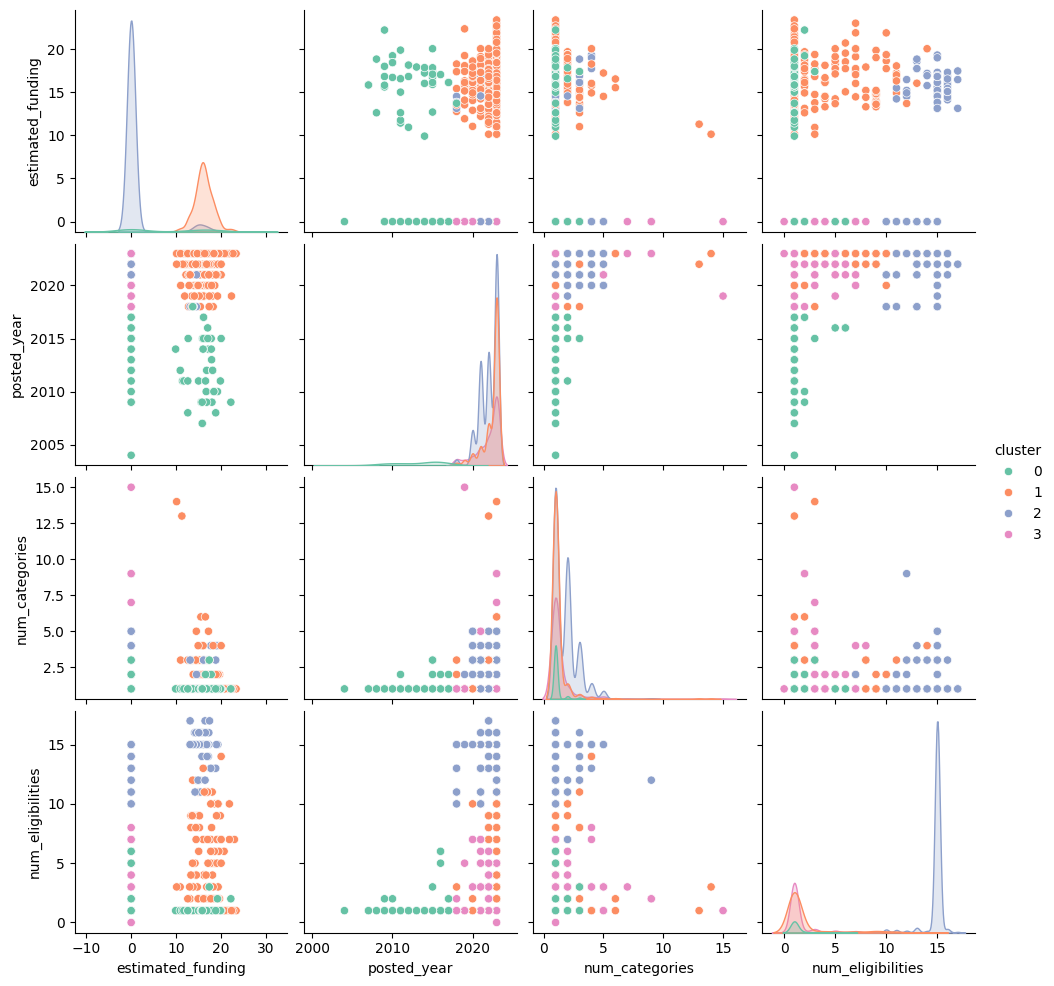

In [ ]:
# Create the copy for random_state=3
df_plot_rs3 = df_cluster.copy()  # df_cluster now has random_state=3 clusters

# Fix the Standardization
df_plot_rs3[['estimated_funding', 'posted_year']] = scaler.inverse_transform(df_plot_rs3[['estimated_funding', 'posted_year']])

# Create eligibility/category counts
elig_cols = [col for col in df_plot_rs3.columns if col.startswith('eligibility_')]
cat_cols = [col for col in df_plot_rs3.columns if col.startswith('category_') and col != 'category_explanation']

df_plot_rs3['num_eligibilities'] = (df_plot_rs3[elig_cols] == 'True').sum(axis=1)
df_plot_rs3['num_categories'] = (df_plot_rs3[cat_cols] == 'True').sum(axis=1)

sns.pairplot(df_plot_rs3[['estimated_funding', 'posted_year', 'num_categories', 'num_eligibilities', 'cluster']],
             hue="cluster",
             palette="Set2")

plt.show()

**Analysis:** Random state acts as a seed for the pseudo-random number generator, determining the specific sequence of "random" operations. Here, I am testing random_state=3 instead of my former random_state=42. I analyzed with a pairplot, to make this part of the notebook more visual.

Comparing this pairplot to my original, while the number labels of the clusters have changed, their actual qualities on this graph look the same. Therefore, they hold up with consistency. I will just keep the random_state=42 clusters as I have already named them.

## **Clustering with just larger Grants table to see if more insightful temporal eras emerge**

Now, I will try clustering on just agency, estimated_funding, and year_posted from the grants column with 74669 rows vs 2000 to see if any insightful eras emerge. This is less detailed than my original chosen clusters with eligibility and category, but could be insightful.

###**1. Preprocessing**

In [ ]:
# Extract year from posted_date
grants['posted_year'] = pd.to_datetime(grants['posted_date']).dt.year

# Fill missing estimated_funding with 0
grants['estimated_funding'] = grants['estimated_funding'].fillna(0) # Keeping this method decided upon in M3

# Log transform estimated_funding
grants['estimated_funding_log'] = np.log1p(grants['estimated_funding'])

# Simplify agency_name to top 10 + Other
top_10_agencies_grants = grants['agency_name'].value_counts().head(10).index
grants['agency_simplified_grants'] = grants['agency_name'].apply(
    lambda x: x if x in top_10_agencies_grants else 'Other')

###**2. Feature selection**

In [ ]:
grants_cols_to_keep = ['estimated_funding_log', 'posted_year', 'agency_simplified_grants']
df_grants_cluster = grants[grants_cols_to_keep].dropna().copy()

###**3. Standardize & convert agency to string for k-prototypes**

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler2 = StandardScaler()
df_grants_cluster[['estimated_funding_log', 'posted_year']] = scaler2.fit_transform(
    df_grants_cluster[['estimated_funding_log', 'posted_year']]
)

In [ ]:
df_grants_cluster['agency_simplified_grants'] = df_grants_cluster['agency_simplified_grants'].astype(str)

###**4. Take random 15% sample**

In [ ]:
df_grants_sample = df_grants_cluster.sample(frac=0.15, random_state=42)
print(f"Sample size: {len(df_grants_sample)} grants")

# Compare descriptive stats to check representativeness
print("\nFull dataset:")
print(df_grants_cluster[['estimated_funding_log', 'posted_year']].describe())
print("\nSample:")
print(df_grants_sample[['estimated_funding_log', 'posted_year']].describe())

Sample size: 11200 grants

Full dataset:
       estimated_funding_log   posted_year
count           7.466900e+04  7.466900e+04
mean           -3.045088e-17  1.230216e-15
std             1.000007e+00  1.000007e+00
min            -1.368955e+00 -2.722851e+00
25%            -1.368955e+00 -8.757179e-01
50%             3.906546e-01  4.784874e-02
75%             8.030376e-01  7.405237e-01
max             2.455617e+00  1.664090e+00

Sample:
       estimated_funding_log   posted_year
count           11200.000000  11200.000000
mean               -0.021040      0.005278
std                 1.002614      0.996120
min                -1.368955     -2.261068
25%                -1.368955     -0.875718
50%                 0.358233      0.047849
75%                 0.793710      0.740524
max                 1.858245      1.664090


**Analysis:** Good representative sample- std is ~1 for both, Mean is ~0 for both. Estimated_funding isnt too far off. I will go ahead with clustering on this sample to speed up clustering processing.

###**5. Elbow method**

k=2 done, cost=14709.76
k=3 done, cost=9648.31
k=4 done, cost=6825.25
k=5 done, cost=5674.85
k=6 done, cost=4963.89
k=7 done, cost=4400.54
k=8 done, cost=4085.52
k=9 done, cost=3902.91
k=10 done, cost=3760.29


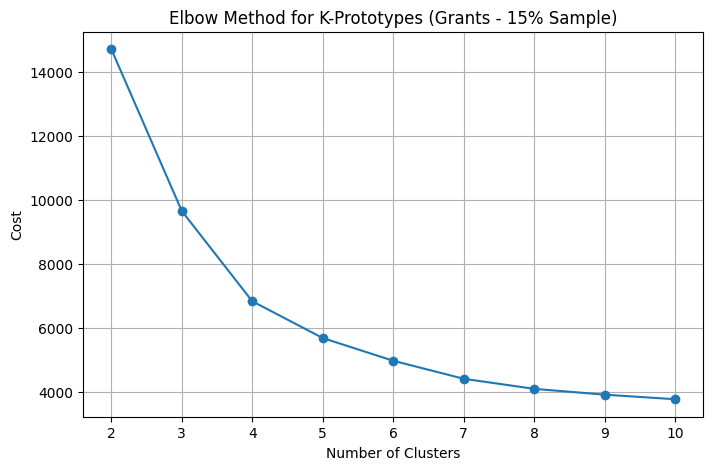

In [ ]:
categorical_cols_grants = [2]  # agency_simplified_grants is index 2

grants_costs = []
k_range = range(2, 11)

for k in k_range:
    kproto_grants = KPrototypes(n_clusters=k, init='Cao', n_init=3, random_state=42)
    kproto_grants.fit_predict(df_grants_sample, categorical=categorical_cols_grants)
    grants_costs.append(kproto_grants.cost_)
    print(f"k={k} done, cost={kproto_grants.cost_:.2f}")

plt.figure(figsize=(8, 5))
plt.plot(k_range, grants_costs, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Cost')
plt.title('Elbow Method for K-Prototypes (Grants - 15% Sample)')
plt.grid(True)
plt.show()

###**6. Cluster with k=4**

K=4 seems like a good elbow to try, as it is also what I finalized my clusters on while using the smaller merged table with eligibilities/categories. This way I can compare effectively.

In [ ]:
from kmodes.kprototypes import KPrototypes

categorical_cols_grants = [2]  # agency_simplified_grants is index 2

kproto_grants = KPrototypes(
    n_clusters=4,
    init='Cao',
    n_init=5,
    verbose=2,
    random_state=42
)

grants_clusters = kproto_grants.fit_predict(
    df_grants_sample,
    categorical=categorical_cols_grants
)

df_grants_sample = df_grants_sample.copy()
df_grants_sample['cluster'] = grants_clusters

Initialization method and algorithm are deterministic. Setting n_init to 1.
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 1, iteration: 1/100, moves: 2708, ncost: 6872.159314051641
Run: 1, iteration: 2/100, moves: 521, ncost: 6825.247803885
Run: 1, iteration: 3/100, moves: 0, ncost: 6825.247803885
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 2, iteration: 1/100, moves: 4905, ncost: 8848.011638988452
Run: 2, iteration: 2/100, moves: 1913, ncost: 6893.758220059855
Run: 2, iteration: 3/100, moves: 337, ncost: 6853.1690724498685
Run: 2, iteration: 4/100, moves: 0, ncost: 6853.1690724498685
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 3, iteration: 1/100, moves: 3309, ncost: 6895.430431372199
Run: 3, iteration: 2/100, moves: 142, ncost: 6865.960631141562
Run: 3, iteration: 3/100, moves: 2, ncost: 6865.957014225236
Run: 3, iteration: 4/100, moves: 0, ncost: 6865.957014225236

In [ ]:
df_grants_readable = df_grants_sample.copy()
df_grants_readable[['estimated_funding_log', 'posted_year']] = scaler2.inverse_transform(
    df_grants_readable[['estimated_funding_log', 'posted_year']]
)
df_grants_readable['estimated_funding'] = np.expm1(df_grants_readable['estimated_funding_log'])

for i in range(4):
    print("\n" + "="*60)
    print(f"               CLUSTER {i} ANALYSIS")
    print("="*60)

    c_data = df_grants_readable[df_grants_readable['cluster'] == i]
    total = len(c_data)

    print(f"Total Grants:   {total}")
    print(f"Typical Year:   {int(c_data['posted_year'].median())}")
    print(f"Year Range:     {int(c_data['posted_year'].min())} to {int(c_data['posted_year'].max())}")
    print(f"Median Funding: ${c_data['estimated_funding'].median():,.2f}")
    print(f"Average Funding: ${c_data['estimated_funding'].mean():,.2f}")

    print("\nTop 3 Agencies:")
    agencies = c_data['agency_simplified_grants'].value_counts().head(3)
    for name, count in agencies.items():
        print(f"  - {name}: {count} grants")


               CLUSTER 0 ANALYSIS
Total Grants:   3806
Typical Year:   2019
Year Range:     2016 to 2023
Median Funding: $1,000,000.00
Average Funding: $19,693,849.91

Top 3 Agencies:
  - Other: 2181 grants
  - National Park Service: 571 grants
  - Fish and Wildlife Service: 207 grants

               CLUSTER 1 ANALYSIS
Total Grants:   3613
Typical Year:   2012
Year Range:     2006 to 2015
Median Funding: $880,000.00
Average Funding: $10,792,944.30

Top 3 Agencies:
  - Other: 1513 grants
  - National Park Service: 527 grants
  - National Institutes of Health: 318 grants

               CLUSTER 2 ANALYSIS
Total Grants:   2516
Typical Year:   2019
Year Range:     2015 to 2023
Median Funding: $0.00
Average Funding: $1.00

Top 3 Agencies:
  - Other: 1335 grants
  - National Institutes of Health: 831 grants
  - National Park Service: 107 grants

               CLUSTER 3 ANALYSIS
Total Grants:   1265
Typical Year:   2011
Year Range:     2006 to 2014
Median Funding: $0.00
Average Funding: $0

**Analysis:** Because this clustering only uses 3 features, clustering ran faster.

**Cluster 0: Modern Funded Era (2016–2023)- 3,806 grants**, typical year 2019, solid $1M median funding. National Park Service and Fish & Wildlife heavy- suggests environmental/conservation grants dominate modern funded grantmaking.

**Cluster 1: Historical Funded Era (2006–2015)- 3,613 grants,** typical year 2012, $880K median. Similar agencies to Cluster 0 but older- the historical equivalent of the modern funded era.

**Cluster 2: Modern Unfunded/Developmental Era (2015–2023)- 2,516 grants,** typical year 2019, $0 median. NIH-heavy- echoes my original dataset's Cluster 3 pattern of unfunded/developmental grants.

**Cluster 3: Historical Unfunded/Developmental Era (2006–2014)- 1,265 grants,** typical year 2011, $0 median. NIH-heavy older grants with no established funding.

My clusters are splitting along two axes simultaneously: time (modern vs. historical) and estimated funding status (funded vs. unfunded-- reflecting maturity and planning status of grant).

**Note on keeping 0s:** I was considering dropping 0s from estimated_funding here, but I chose to not do that in my original clustering as many grants would be then unconsidered in clustering (maybe less mature or in-progress grants with 0 in estimated_funding exist, and perhaps wound up getting funding.) So I will stay consistent and they will be considered here as well.

While I will be sticking with my **more detailed temporal eras,** these eras add deeper insights and context with more data! I will incorporate these into my business insights below.

## **Text Mining Consideration/Note**

My selected features used in my clustering do not involve any unstructured data that would produce semantic richness with text mining. My object/string feature "Agency" has rows like "National Institutes of Health," which is not what we are looking for in terms of unstructured  descriptive text. Descriptive longer text are out of scope for my chosen features, so I will not be harnessing it in my analysis.

Conducting  text mining on a column that doesn't belong to my features and overlaps with teammates' research questions (descriptions, eligibility) would leave my component less focused.

## **Business Insights**

**Final overarching analysis:** Ultimately, **some "era" clusters did come about** from unsupervised machine learning clustering using k-prototypes. One older cluster and three more modern clusters formed. These also had some unique policy priorities. The largest cluster (0) encapsulates health and social infrastructure, Cluster 1 involves an earlier era (2004 to 2018) of more fragmented funding (at least what was tracked into the dataset), Cluster 2 involves high-investment science and military, and Cluster 3 showcases a variety of agencies including "other" (less common ones), NIH, and NASA grants without established grant funding amounts ("\$0").

Relating to **COVID,** 2020-time was a clear inflection point when federal grant-making exploded (at least, what was tracked in the Details/Merged table, but this is also reflected in the large Grants funding graph in EDA 2.2 in M2). This is especially the case for health, but also broadly across science, education, and environment. My clustering captured this, with the public health (NIH, CDC)-focused cluster (Cluster 0) likely playing a major part in the pandemic response era.

To further validate these findings, a **parallel clustering** on the larger Grants table produced four similarly interpretable clusters, splitting along two axes: time (modern vs. historical) and estimated funding status (funded vs. unfunded). The modern funded cluster was dominated by National Park Service and Fish & Wildlife grants ($1M median), while the modern unfunded cluster mirrored my original cluster 3 (modern non-established).

**Federal agencies and policy analysts** can plan and strategize based on my clusters. For example, Cluster 0 suggests that during health crises like COVID, NIH-led grants with broad institutional eligibility scale rapidly, signaling where emergency resources should be pre-positioned. Grant applicants can use Cluster 2's profile (NSF/Army-driven, high-dollar, low eligibility) to identify whether they fit the competitive STEM funding archetype, while Cluster 3's $0 pattern warns that many modern grants are still in developmental stages. The older Cluster 1 offers a baseline to show how funding has shifted since. More data/rows/over a longer period of time would aid this analysis, but my attempt to use just the Grants table created a limitation of not enough detailed features in clusters.

**AI Disclosure:** My written M4 report includes a link to my conversations with AI chatbot Claude, which helped me strategize, modify, and understand the updated findings in this notebook.